In [1]:
# Standard code libraries
import sys
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

%matplotlib widget

In [2]:
t_end = 30
fs = 2048
t = np.arange(0, t_end, 1/fs)
np.random.seed(42)


## Simulate with different Neurokit versions

In [3]:
ecg_t_end = 10
fs_ecg = 1000
sim_hr = 70
np.random.seed(42)
random_state = 42
# ecg_sim = nk.ecg_simulate(
#         duration=ecg_t_end,
#         sampling_rate=fs_ecg,
#         heart_rate=sim_hr,
#         random_state=random_state
#     )
ecg_sim = nk.ecg_simulate(
        duration=ecg_t_end,
        sampling_rate=fs_ecg,
        heart_rate=sim_hr,
    )


In [4]:
np_version = np.__version__.replace('.', '_')
nk_version = nk.__version__.replace('.', '_')
print(f"NumPy version: {np.__version__}")
print(f"NeuroKit version: {nk.__version__}")

NumPy version: 2.0.1
NeuroKit version: 0.2.9


In [5]:
neurokit2_version = nk.__version__.replace('.', '_')
np.save(f'NK_{neurokit2_version}_test_ecg.npy', ecg_sim)

with open(f"nk_{nk_version}_version_info.txt", "w", encoding="utf-8") as f:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "freeze"],
        capture_output=True,
        text=True, 
        check=True,
    )
    wanted = ("numpy", "scipy", "pandas", "neurokit2")
    for line in result.stdout.splitlines():
        if line.lower().startswith(wanted):
            f.write(line + "\n")


## Load files generated with different Neurokit versions

Text(0.5, 0, 'Time (s)')

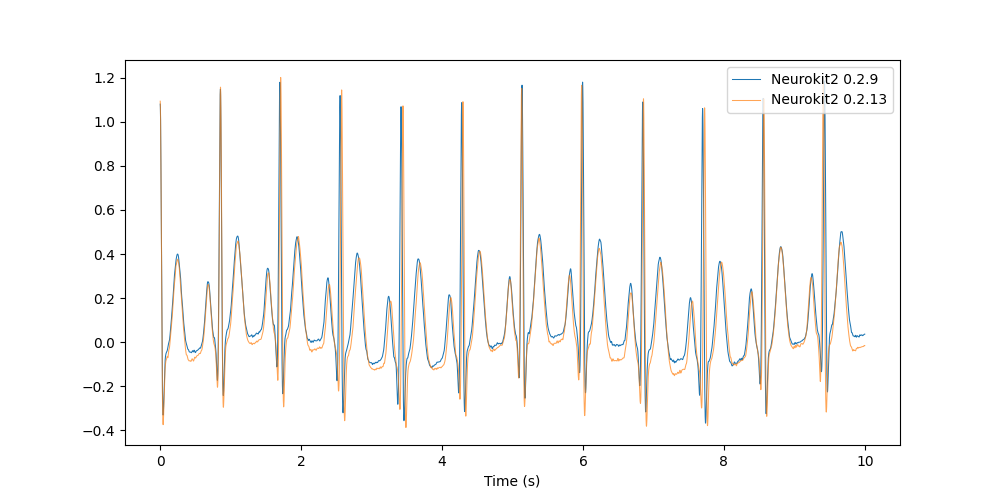

In [6]:
ecg_np_2_0_1 = np.load('NK_0_2_9_test_ecg.npy')
ecg_np_2_4_4 = np.load('NK_0_2_13_test_ecg.npy')
fig, ax = plt.subplots(figsize=(10, 5))
t = np.arange(0, ecg_t_end, 1/fs_ecg)
# ax.plot(t[t < 10], ecg_np_2_0_1[t < 10], label='NumPy 2.0.1', linewidth=0.75)
# ax.plot(t[t < 10], ecg_np_2_4_4[t < 10], label='NumPy 2.4.4', linewidth=0.75, alpha=0.7)
ax.plot(t[t < 10], ecg_np_2_0_1[t < 10], label='Neurokit2 0.2.9', linewidth=0.75)
ax.plot(t[t < 10], ecg_np_2_4_4[t < 10], label='Neurokit2 0.2.13', linewidth=0.75, alpha=0.7)
# ax.plot(t[t < 10], ecg_sim[t < 10], label='Original ECG', linewidth=0.75, alpha=0.7, linestyle='--', color='black')
ax.legend()
ax.set_xlabel('Time (s)')